# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [1]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, vali_loader, test_loader = dataset.get_train_val_test_loader()

Train samples: 16052
Validation samples: 1784
Test samples: 4460


c:\Users\cocon\Desktop\epidemic-transformer-forecasting\dataset.py:49: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  torch.tensor(x_train, dtype=torch.float32).unsqueeze(-1),


## ARIMA - Baseline Part

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.arima.model import ARIMA

import statsmodels
import logging
logging.getLogger("statsmodels").setLevel(logging.ERROR)

In [3]:
# Load State-level ILI data 
# Modified: use state-level data to match the Transformer dataset
df_state = pd.read_csv("./data/state/ILINet.csv", header=1)

target_col = "%UNWEIGHTED ILI"

# Modified: make sure ILI values are numeric and remove invalid rows
df_state[target_col] = pd.to_numeric(df_state[target_col], errors="coerce")
df_state = df_state.dropna(subset=[target_col])

print(f"Total rows loaded : {len(df_state)}")
print(f"Number of regions : {df_state['REGION'].nunique()}")
print(f"ILI range         : {df_state[target_col].min():.3f} ~ {df_state[target_col].max():.3f}")

# Sliding window — must match dataset.py parameters exactly
HISTORY = 10   # Input: Past 10 weeks
FUTURE  = 4    # Output: 4 weeks
TEST_SIZE = 0.2

X, Y = [], []

# Modified: build sliding windows separately for each state/region
for region, group in df_state.groupby("REGION"):
    group = group.sort_values(["YEAR", "WEEK"])
    series = group[target_col].values.astype(float)

    if len(series) < HISTORY + FUTURE:
        continue

    # Modified: +1 keeps the last valid sliding window
    for i in range(len(series) - HISTORY - FUTURE + 1):
        X.append(series[i : i + HISTORY])
        Y.append(series[i + HISTORY : i + HISTORY + FUTURE])

X = np.array(X)  # (n_samples, 10)
Y = np.array(Y)  # (n_samples, 4)

split_idx = int(len(X) * (1 - TEST_SIZE))
X_test = X[split_idx:]
Y_test = Y[split_idx:]

print(f"\nTotal sliding windows : {len(X)}")
print(f"Test set size         : {len(X_test)} windows")
print(f"Each window           : {HISTORY} weeks in -> {FUTURE} weeks out")

Total rows loaded : 22310
Number of regions : 54
ILI range         : 0.000 ~ 19.418

Total sliding windows : 21608
Test set size         : 4322 windows
Each window           : 10 weeks in -> 4 weeks out


In [4]:
def arima_predict_window(history_window, order=(3, 0, 3), steps=4): 
    """
    Given a history window of length HISTORY, forecast the next `steps` values.
 
    Paper setting: ARIMA(3, 0, 3) with constant trend, order chosen by AIC/BIC.
 
    Args:
        history_window : np.array of shape (HISTORY,)
        order          : (p, d, q) tuple
        steps          : number of future steps to forecast
    Returns:
        np.array of shape (steps,)
    """
    try:
        model = ARIMA(history_window, order=order, trend="c")
        fit   = model.fit(method_kwargs={"maxiter": 200})
        pred  = fit.forecast(steps=steps)

        # Modified: check invalid ARIMA outputs
        if np.any(np.isnan(pred)) or np.any(np.isinf(pred)):
            raise ValueError("Invalid ARIMA prediction")

        # Modified: return prediction and fallback flag
        return pred, False

    except Exception:
        # Fallback: repeat the last observed value if fitting fails
        # Modified: return fallback flag
        return np.full(steps, history_window[-1]), True
 
 
print("Running ARIMA(3,0,3) predictions...")
all_preds = []

# Modified: track how often ARIMA fitting fails
fallback_count = 0
 
for i, window in enumerate(X_test):
    # Modified: receive both prediction and fallback flag
    pred, used_fallback = arima_predict_window(window, order=(3, 0, 3), steps=FUTURE)
    all_preds.append(pred)

    # Modified: count fallback cases
    if used_fallback:
        fallback_count += 1

    # Modified: print less often because state-level test set is much larger
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(X_test)} windows done...")
 
all_preds  = np.array(all_preds)   # shape: (n_test, 4)
all_labels = Y_test                 # shape: (n_test, 4)

print("Done!")

# Modified: report fallback information
print(f"Fallback count: {fallback_count}")
print(f"Fallback rate : {fallback_count / len(X_test):.4f}")

Running ARIMA(3,0,3) predictions...


c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  500/4322 windows done...


c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  1000/4322 windows done...


...

  3500/4322 windows done...


c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  4000/4322 windows done...


c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\cocon\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

Done!
Fallback count: 0
Fallback rate : 0.0000


In [5]:
print("\n" + "="*50) 
print("  ARIMA(3,0,3) Baseline Results")
print("="*50)
 
arima_metrics = {}
for step in range(FUTURE):
    p  = all_preds[:, step]
    l  = all_labels[:, step]
    rmse       = np.sqrt(np.mean((p - l) ** 2))
    mae        = np.mean(np.abs(p - l))

    # Modified: avoid Pearson error when prediction or label has zero variance
    if np.std(p) == 0 or np.std(l) == 0:
        pearson = np.nan
    else:
        pearson, _ = pearsonr(p, l)

    print(f"  Week+{step+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={pearson:.4f}")
    arima_metrics[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": pearson}
 
# Overall metrics (flatten all steps)
p_all          = all_preds.flatten()
l_all          = all_labels.flatten()
overall_rmse    = np.sqrt(np.mean((p_all - l_all) ** 2))
overall_mae     = np.mean(np.abs(p_all - l_all))

# Modified: avoid Pearson error when prediction or label has zero variance
if np.std(p_all) == 0 or np.std(l_all) == 0:
    overall_pearson = np.nan
else:
    overall_pearson, _ = pearsonr(p_all, l_all)
 
print("-"*50)
print(f"  Overall : RMSE={overall_rmse:.4f}  MAE={overall_mae:.4f}  Pearson={overall_pearson:.4f}")
print("="*50)
print("\n-> This is the baseline. The Transformer should beat these numbers!")
 
arima_metrics["overall"] = {
    "rmse": overall_rmse, "mae": overall_mae, "pearson": overall_pearson
}


  ARIMA(3,0,3) Baseline Results
  Week+1: RMSE=0.8135  MAE=0.4979  Pearson=0.8687
  Week+2: RMSE=1.1715  MAE=0.7074  Pearson=0.7410
  Week+3: RMSE=1.4767  MAE=0.8972  Pearson=0.6070
  Week+4: RMSE=1.6825  MAE=1.0336  Pearson=0.4994
--------------------------------------------------
  Overall : RMSE=1.3272  MAE=0.7840  Pearson=0.6731

-> This is the baseline. The Transformer should beat these numbers!


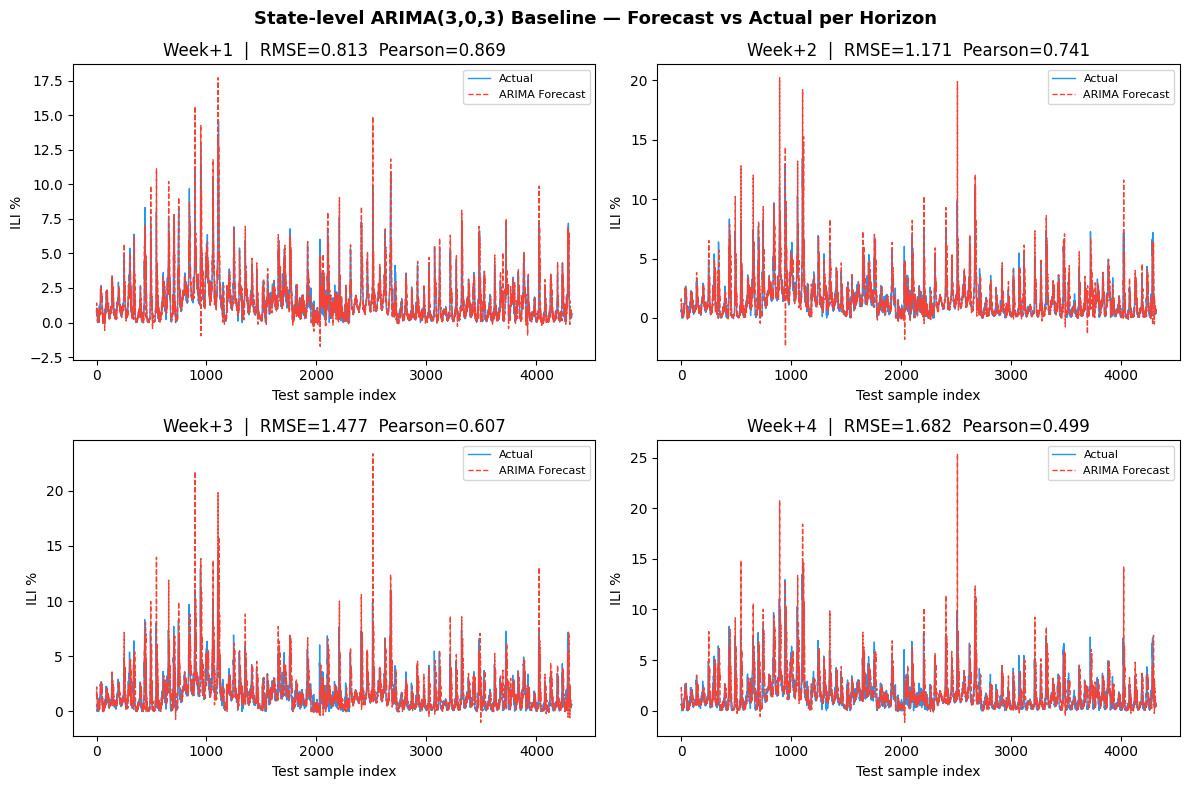

Plot saved: arima_state_baseline_results.png
Saved:
  arima_state_preds.npy   — State-level ARIMA predictions, shape (n_test, 4)
  arima_state_labels.npy  — Ground truth labels, shape (n_test, 4)

Load these later to compare directly with Transformer results.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 
fig.suptitle("State-level ARIMA(3,0,3) Baseline — Forecast vs Actual per Horizon",
             fontsize=13, fontweight="bold")  # Modified: clarify this is state-level ARIMA
 
for step in range(FUTURE):
    ax   = axes[step // 2][step % 2]
    rmse = arima_metrics[f"week{step+1}"]["rmse"]
    r    = arima_metrics[f"week{step+1}"]["pearson"]
 
    ax.plot(all_labels[:, step], color="#2196F3", linewidth=1.0, label="Actual")
    ax.plot(all_preds[:, step],  color="#F44336", linewidth=1.0,
            linestyle="--", label="ARIMA Forecast")
    ax.set_title(f"Week+{step+1}  |  RMSE={rmse:.3f}  Pearson={r:.3f}")
    ax.set_ylabel("ILI %")
    ax.set_xlabel("Test sample index")
    ax.legend(fontsize=8)
 
plt.tight_layout()

# Modified: use clearer filename for state-level ARIMA baseline
plt.savefig("arima_state_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: arima_state_baseline_results.png")
 

# Modified: use clearer filenames for state-level ARIMA outputs
np.save("arima_state_preds.npy",  all_preds)
np.save("arima_state_labels.npy", all_labels)

print("Saved:")
print("  arima_state_preds.npy   — State-level ARIMA predictions, shape (n_test, 4)")
print("  arima_state_labels.npy  — Ground truth labels, shape (n_test, 4)")
print("\nLoad these later to compare directly with Transformer results.")

## Deep Transformer Model

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt


class DeepTransformer:
    pass

In [8]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for xb, yb in self.train_loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.optimizer.zero_grad()
    
            pred = None
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for xb, yb in dataloader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
    
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

ARIMA - Baseline Part

In [9]:
import pandas as pd

# Modified: inspect state-level data to match the ARIMA baseline setting
df = pd.read_csv("./data/state/ILINet.csv", header=1)

print(df.columns.tolist())
print(df.head(3))
print(len(df))

['REGION TYPE', 'REGION', 'YEAR', 'WEEK', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']
  REGION TYPE   REGION  YEAR  WEEK % WEIGHTED ILI  %UNWEIGHTED ILI AGE 0-4  \
0      States  Alabama  2010    40              X         2.134770       X   
1      States   Alaska  2010    40              X         0.875146       X   
2      States  Arizona  2010    40              X         0.674721       X   

  AGE 25-49 AGE 25-64 AGE 5-24 AGE 50-64 AGE 65  ILITOTAL  NUM. OF PROVIDERS  \
0         X         X        X         X      X       249                 35   
1         X         X        X         X      X        15                  7   
2         X         X        X         X      X       172                 49   

   TOTAL PATIENTS  
0           11664  
1            1714  
2           25492  
22310


# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case